# SVM Final Selected Model

Fits the manually selected SVM hyperparameters and evaluates the held-out test cache exactly once.

This notebook **does not rescan audio or extract MFCCs**. It loads the shared SVM cache created by `00_SVM_Data_Preparation.ipynb`.


## 1. Environment Setup


In [1]:
import os
from pathlib import Path

# Purpose: Mounts Google Drive when this notebook is running in Google Colab.
# Why this exists: the shared SVM feature cache, manifests, configs, models,
# figures, and metric outputs may live under /content/drive/MyDrive in Colab.
# A /content/drive path is only reliable after Google Drive has actually been mounted.
# This cell is kept separate and early so the rest of the notebook can resolve paths safely.

COLAB_DRIVE_MOUNT_POINT = Path("/content/drive")
EXPECTED_COLAB_PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/Education/INM701")

try:
    from google.colab import drive

    drive.mount("/content/drive")
    os.environ.setdefault(
        "INTRO_AI_PROJECT_ROOT",
        str(EXPECTED_COLAB_PROJECT_ROOT),
    )
    print("Google Colab detected. Google Drive mounted.")
except Exception as exc:
    print("Google Colab Drive mount skipped. This is expected outside Colab.")
    print("Mount skip reason:", exc)

print("INTRO_AI_PROJECT_ROOT:", os.environ.get("INTRO_AI_PROJECT_ROOT", "not set"))


Mounted at /content/drive
Google Colab detected. Google Drive mounted.
INTRO_AI_PROJECT_ROOT: /content/drive/MyDrive/Colab Notebooks/Education/INM701


In [2]:
import importlib.util
import subprocess
import sys

required_packages = [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("sklearn", "scikit-learn"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("joblib", "joblib"),
]
missing = [pip_name for import_name, pip_name in required_packages if importlib.util.find_spec(import_name) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("Required packages are already installed.")


Required packages are already installed.


## 2. Load Shared SVM Cache


In [3]:
import json
import os
import random
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.svm import SVC

try:
    from IPython.display import display
except Exception:
    display = print

RANDOM_STATE = 42
SVM_MAX_TRAIN_SAMPLES = 20000
CLASS_NAMES = {0: "bona_fide", 1: "synthetic"}
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)


def resolve_project_root():
    explicit = os.environ.get("INTRO_AI_PROJECT_ROOT")
    if explicit:
        return Path(explicit).expanduser().resolve()
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "Data").exists() or (candidate / "Datasets").exists() or (candidate / "outputs").exists():
            return candidate
        if (candidate / "Model Variants").exists():
            return candidate
        if (candidate / "Training" / "Model Variants").exists():
            return candidate / "Training"
    return Path("/content/drive/MyDrive/Colab Notebooks/Education/INM701")


PROJECT_ROOT = resolve_project_root()
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "svm"
CACHE_DIR = OUTPUT_DIR / "cache"
MANIFESTS_DIR = OUTPUT_DIR / "manifests"
CONFIGS_DIR = OUTPUT_DIR / "configs"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
for directory in [OUTPUT_DIR, CACHE_DIR, MANIFESTS_DIR, CONFIGS_DIR, TABLE_DIR, FIGURE_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


def require_file(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Required shared-cache artifact not found: {path}. "
            "Run 00_SVM_Data_Preparation.ipynb first."
        )
    return path


def load_json(path):
    with open(require_file(path), "r", encoding="utf-8") as file:
        return json.load(file)


for required in [
    CACHE_DIR / "X_train.npy",
    CACHE_DIR / "y_train.npy",
    CACHE_DIR / "train_metadata.csv",
    CACHE_DIR / "X_validation.npy",
    CACHE_DIR / "y_validation.npy",
    CACHE_DIR / "validation_metadata.csv",
    CACHE_DIR / "feature_config.json",
    CACHE_DIR / "svm_standard_scaler.joblib",
]:
    require_file(required)

X_train_scaled = np.load(CACHE_DIR / "X_train.npy", mmap_mode="r")
y_train = np.load(CACHE_DIR / "y_train.npy")
train_metadata = pd.read_csv(CACHE_DIR / "train_metadata.csv")
X_validation_scaled = np.load(CACHE_DIR / "X_validation.npy", mmap_mode="r")
y_validation = np.load(CACHE_DIR / "y_validation.npy")
validation_metadata = pd.read_csv(CACHE_DIR / "validation_metadata.csv")
feature_config = load_json(CACHE_DIR / "feature_config.json")
scaler = joblib.load(CACHE_DIR / "svm_standard_scaler.joblib")

if len(X_train_scaled) != len(y_train) or len(X_train_scaled) != len(train_metadata):
    raise RuntimeError("Training cache arrays, labels and metadata are not row-aligned.")
if len(X_validation_scaled) != len(y_validation) or len(X_validation_scaled) != len(validation_metadata):
    raise RuntimeError("Validation cache arrays, labels and metadata are not row-aligned.")
if X_train_scaled.ndim != 2 or X_train_scaled.shape[1] != 80:
    raise RuntimeError(f"Expected 80-dimensional aggregated MFCC vectors, got {X_train_scaled.shape}")

LOAD_TEST_CACHE = True
if LOAD_TEST_CACHE:
    for required in [
        CACHE_DIR / "X_test.npy",
        CACHE_DIR / "y_test.npy",
        CACHE_DIR / "test_metadata.csv",
    ]:
        require_file(required)
    X_test_scaled = np.load(CACHE_DIR / "X_test.npy", mmap_mode="r")
    y_test = np.load(CACHE_DIR / "y_test.npy")
    test_metadata = pd.read_csv(CACHE_DIR / "test_metadata.csv")
    if len(X_test_scaled) != len(y_test) or len(X_test_scaled) != len(test_metadata):
        raise RuntimeError("Test cache arrays, labels and metadata are not row-aligned.")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Loaded shared SVM cache:", CACHE_DIR)
print("X_train shape:", X_train_scaled.shape)
print("X_validation shape:", X_validation_scaled.shape)
print("Test cache loaded:", LOAD_TEST_CACHE)


PROJECT_ROOT: /content/drive/MyDrive/Colab Notebooks/Education/INM701
Loaded shared SVM cache: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/svm/cache
X_train shape: (9060, 80)
X_validation shape: (1942, 80)
Test cache loaded: True


## 3. Reproducible SVM Training Subset


In [4]:
if len(y_train) > SVM_MAX_TRAIN_SAMPLES:
    selected = np.random.default_rng(RANDOM_STATE).choice(
        len(y_train), size=SVM_MAX_TRAIN_SAMPLES, replace=False
    )
    X_fit = X_train_scaled[selected]
    y_fit = y_train[selected]
    print(f"Training on the same reproducible {SVM_MAX_TRAIN_SAMPLES}-row subset.")
else:
    X_fit = X_train_scaled
    y_fit = y_train
    print(f"Training on all {len(y_fit)} training rows.")


Training on all 9060 training rows.


## 4. Evaluation Helper


In [5]:
def evaluate_classifier(model, X, y_true, variant, split_name):
    y_pred = model.predict(X)
    return {
        "variant": variant,
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }, y_pred


## 5. Final Selected Hyperparameters


In [6]:
# IMPORTANT: update these four values using your completed individual trial results
# BEFORE treating the test metrics as your dissertation's final SVM result.
FINAL_KERNEL = "rbf"
FINAL_C = 1.0
FINAL_GAMMA = "scale"
FINAL_CLASS_WEIGHT = "balanced"

final_params = {
    "variant": "final_selected_svm",
    "kernel": FINAL_KERNEL,
    "C": FINAL_C,
    "gamma": FINAL_GAMMA,
    "class_weight": FINAL_CLASS_WEIGHT,
}

display(pd.DataFrame([final_params]))


,variant,kernel,C,gamma,class_weight
0,final_selected_svm,rbf,1.0,scale,balanced


## 6. Final Held-Out Test Evaluation


In [7]:
final_model = SVC(
    kernel=final_params["kernel"],
    C=final_params["C"],
    gamma=final_params["gamma"],
    class_weight=final_params["class_weight"],
    random_state=RANDOM_STATE,
)
final_model.fit(X_fit, y_fit)

# The held-out test cache is loaded only in this final-model notebook.
test_metrics, y_test_pred = evaluate_classifier(
    final_model,
    X_test_scaled,
    y_test,
    final_params["variant"],
    "test",
)
test_metrics.update({k: v for k, v in final_params.items() if k != "variant"})

test_results = pd.DataFrame([test_metrics])
test_path = TABLE_DIR / "svm_final_test_metrics.csv"
test_results.to_csv(test_path, index=False)
display(test_results)
print("Saved final test metrics:", test_path)


,variant,split,accuracy,precision,recall,f1,kernel,C,gamma,class_weight
0,final_selected_svm,test,0.952626,0.995246,0.935917,0.96467,rbf,1.0,scale,balanced


Saved final test metrics: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/svm/tables/svm_final_test_metrics.csv


## 7. Confusion Matrix


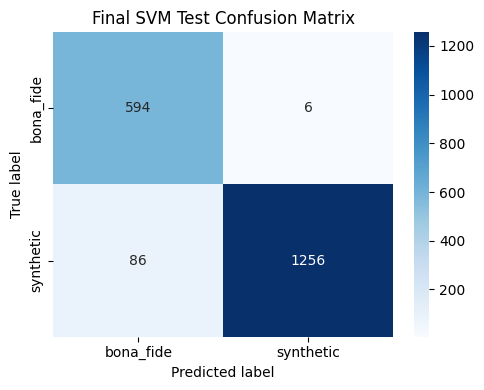

Saved confusion matrix: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/svm/figures/svm_final_test_confusion_matrix.png


In [8]:
matrix = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
plt.figure(figsize=(5, 4))
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[CLASS_NAMES[0], CLASS_NAMES[1]],
    yticklabels=[CLASS_NAMES[0], CLASS_NAMES[1]],
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Final SVM Test Confusion Matrix")
plt.tight_layout()

confusion_path = FIGURE_DIR / "svm_final_test_confusion_matrix.png"
plt.savefig(confusion_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved confusion matrix:", confusion_path)


## 8. Save Final Model and Scaler


In [9]:
model_path = MODEL_DIR / "svm_final_selected_model.joblib"
scaler_path = MODEL_DIR / "svm_standard_scaler.joblib"
joblib.dump(final_model, model_path)
joblib.dump(scaler, scaler_path)

print("Saved final model:", model_path)
print("Saved scaler:", scaler_path)
print("Saved test metrics:", test_path)
print("Saved confusion matrix:", confusion_path)


Saved final model: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/svm/models/svm_final_selected_model.joblib
Saved scaler: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/svm/models/svm_standard_scaler.joblib
Saved test metrics: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/svm/tables/svm_final_test_metrics.csv
Saved confusion matrix: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/svm/figures/svm_final_test_confusion_matrix.png
